In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier

from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

In [2]:
# Read data
df = pd.read_csv('Data Files/customer_churn_encoded.csv')
df.head()

,customerid,city,zip_code,latitude,longitude,gender,senior_citizen,partner,dependents,tenure_months,...,tech_support_Yes,streaming_tv_No internet service,streaming_tv_Yes,streaming_movies_No internet service,streaming_movies_Yes,contract_One year,contract_Two year,payment_method_Credit card (automatic),payment_method_Electronic check,payment_method_Mailed check
0,3668-QPYBK,Los Angeles,90003,33.964131,-118.272783,1,0,0,0,2,...,0,0,0,0,0,0,0,0,0,1
1,9237-HQITU,Los Angeles,90005,34.059281,-118.307420,0,0,0,1,2,...,0,0,0,0,0,0,0,0,1,0
2,9305-CDSKC,Los Angeles,90006,34.048013,-118.293953,0,0,0,1,8,...,0,0,1,0,1,0,0,0,1,0
3,7892-POOKP,Los Angeles,90010,34.062125,-118.315709,0,0,1,1,28,...,1,0,1,0,1,0,0,0,1,0
4,0280-XJGEX,Los Angeles,90015,34.039224,-118.266293,1,0,0,1,49,...,0,0,1,0,1,0,0,0,0,0


In [3]:
# Remove columns
cols_to_drop = [
    'customerid',  
    'churn_value', 
    'churn_score', 
    'cltv', 
    'city', 
    'zip_code', 
    'latitude', 
    'longitude'
]

X = df.drop(columns=[col for col in cols_to_drop if col in df.columns])
y = df['churn_value']

print(f"Features shape: {X.shape}")

Features shape: (7043, 35)


In [4]:
# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Original Training Class Distribution:\n{y_train.value_counts(normalize=True) * 100}")

# Apply SMOTE ONLY to Training Data
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print(f"\nSMOTE Training Class Distribution:\n{y_train_smote.value_counts(normalize=True) * 100}")

Original Training Class Distribution:
churn_value
0    73.464679
1    26.535321
Name: proportion, dtype: float64

SMOTE Training Class Distribution:
churn_value
0    50.0
1    50.0
Name: proportion, dtype: float64


In [5]:
# Feature Scaling
scaler = StandardScaler()

# Fit on SMOTE training data, then transform
X_train_scaled = scaler.fit_transform(X_train_smote)
X_test_scaled = scaler.transform(X_test)

# convert to dataframe
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X.columns)

In [6]:
# Initialize the Base Models
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42),
    "CatBoost": CatBoostClassifier(verbose=0, random_state=42) 
}

results = {}

# Train and Evaluate
for name, model in models.items():
    model.fit(X_train_scaled, y_train_smote)

    y_pred = model.predict(X_test_scaled)
    y_proba = model.predict_proba(X_test_scaled)[:, 1]

    roc_auc = roc_auc_score(y_test, y_proba)

    roc_auc = roc_auc_score(y_test, y_proba)
    results[name] = {"Model": model, "ROC-AUC": roc_auc}
    
    # Print Results
    print(f"--- {name} ---")
    print(f"ROC-AUC Score: {roc_auc:.4f}")
    print(classification_report(y_test, y_pred))
    print("-" * 50 + "\n")

--- Logistic Regression ---
ROC-AUC Score: 0.8461
              precision    recall  f1-score   support

           0       0.87      0.83      0.85      1035
           1       0.59      0.66      0.62       374

    accuracy                           0.79      1409
   macro avg       0.73      0.75      0.74      1409
weighted avg       0.80      0.79      0.79      1409

--------------------------------------------------

--- Random Forest ---
ROC-AUC Score: 0.8381
              precision    recall  f1-score   support

           0       0.86      0.85      0.85      1035
           1       0.60      0.61      0.60       374

    accuracy                           0.79      1409
   macro avg       0.73      0.73      0.73      1409
weighted avg       0.79      0.79      0.79      1409

--------------------------------------------------



C:\Users\HP\miniconda3\envs\churnenv\lib\site-packages\xgboost\training.py:200: UserWarning: [01:50:42] WARNING: D:\bld\xgboost-split_1780806771950\work\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


--- XGBoost ---
ROC-AUC Score: 0.8289
              precision    recall  f1-score   support

           0       0.85      0.83      0.84      1035
           1       0.56      0.59      0.58       374

    accuracy                           0.77      1409
   macro avg       0.71      0.71      0.71      1409
weighted avg       0.77      0.77      0.77      1409

--------------------------------------------------

--- CatBoost ---
ROC-AUC Score: 0.8437
              precision    recall  f1-score   support

           0       0.86      0.84      0.85      1035
           1       0.59      0.62      0.60       374

    accuracy                           0.78      1409
   macro avg       0.72      0.73      0.73      1409
weighted avg       0.79      0.78      0.79      1409

--------------------------------------------------



In [7]:
# Hyperparameter tuning for cat boost

from sklearn.model_selection import RandomizedSearchCV

print("Starting Hyperparameter Tuning for CatBoost...")

# Define the grid of parameters to test
cat_param_grid = {
    'depth': [4, 6, 8],
    'learning_rate': [0.01, 0.05, 0.1], 
    'iterations': [100, 250, 500], 
    'l2_leaf_reg': [1, 3, 5, 9]
}

cat_base = CatBoostClassifier(verbose=0, random_state=42)

cat_random_search = RandomizedSearchCV(
    estimator=cat_base,
    param_distributions=cat_param_grid,
    n_iter=15, 
    scoring='roc_auc', 
    cv=5,  
    n_jobs=-1,  
    random_state=42
)

# Fit the Random Search to SMOTE training data
cat_random_search.fit(X_train_scaled, y_train_smote)

best_cat_model = cat_random_search.best_estimator_

# Evaluate
y_pred_tuned = best_cat_model.predict(X_test_scaled)
y_proba_tuned = best_cat_model.predict_proba(X_test_scaled)[:, 1]

roc_auc_tuned = roc_auc_score(y_test, y_proba_tuned)

print(f"Best Parameters Found: {cat_random_search.best_params_}")
print(f"Tuned ROC-AUC Score: {roc_auc_tuned:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_tuned))

Starting Hyperparameter Tuning for CatBoost...
Best Parameters Found: {'learning_rate': 0.1, 'l2_leaf_reg': 9, 'iterations': 250, 'depth': 8}
Tuned ROC-AUC Score: 0.8374

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.84      0.85      1035
           1       0.58      0.60      0.59       374

    accuracy                           0.78      1409
   macro avg       0.72      0.72      0.72      1409
weighted avg       0.78      0.78      0.78      1409



In [9]:
!pip install shap

   ---------------------------------------- 0.0/547.0 kB ? eta -:--:--
   ---------------------------------------- 547.0/547.0 kB 4.5 MB/s  0:00:00
   ---------------------------------------- 0.0/2.7 MB ? eta -:--:--
   ---------------------- ----------------- 1.6/2.7 MB 8.4 MB/s eta 0:00:01
   ---------------------------------------- 2.7/2.7 MB 6.9 MB/s  0:00:00
   ---------------------------------------- 0.0/38.1 MB ? eta -:--:--
   - -------------------------------------- 1.3/38.1 MB 9.6 MB/s eta 0:00:04
   -- ------------------------------------- 2.6/38.1 MB 6.3 MB/s eta 0:00:06
   ---- ----------------------------------- 4.5/38.1 MB 7.1 MB/s eta 0:00:05
   ------ --------------------------------- 6.0/38.1 MB 7.1 MB/s eta 0:00:05
   ------- -------------------------------- 7.6/38.1 MB 7.2 MB/s eta 0:00:05
   --------- ------------------------------ 9.4/38.1 MB 7.4 MB/s eta 0:00:04
   ----------- ---------------------------- 11.3/38.1 MB 7.7 MB/s eta 0:00:04
   ------------- -------

Top 10 Drivers of Churn:
(Positive values drive customers to Leave. Negative values make them Stay.)
                        Feature  Coefficient
                 total_services     4.467947
                monthly_charges     2.840530
payment_method_Electronic check    -2.798404
                  phone_service    -2.699642
                   payment_risk     2.489294
               streaming_tv_Yes    -1.485315
                  tenure_months    -1.481963
           streaming_movies_Yes    -1.476648
              online_backup_Yes    -1.349257
            online_security_Yes    -1.348859


Generating SHAP Summary Plot...


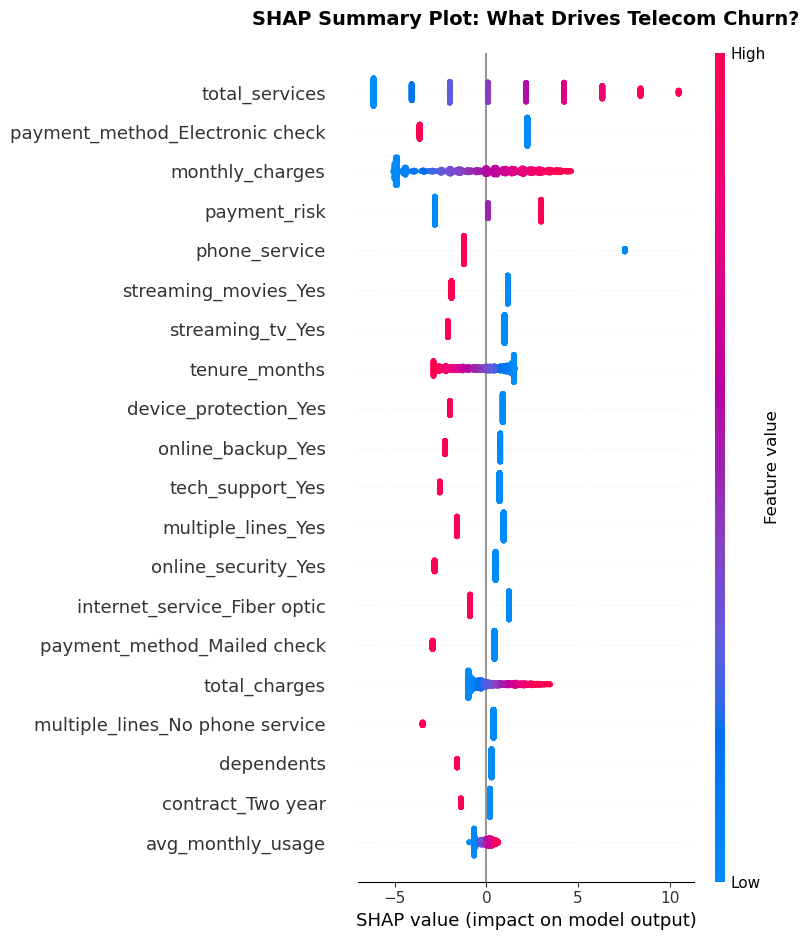

In [11]:
import shap

final_model = models["Logistic Regression"]

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': final_model.coef_[0]
}).sort_values(by='Coefficient', key=abs, ascending=False)

print("Top 10 Drivers of Churn:")
print("(Positive values drive customers to Leave. Negative values make them Stay.)")
print(feature_importance.head(10).to_string(index=False))
print("\n" + "="*50 + "\n")

# Generate SHAP Values
print("Generating SHAP Summary Plot...")

explainer = shap.LinearExplainer(final_model, X_train_scaled)
shap_values = explainer.shap_values(X_test_scaled)

# Plot the SHAP Summary
plt.figure(figsize=(10, 8))
plt.title("SHAP Summary Plot: What Drives Telecom Churn?", fontsize=14, fontweight='bold', pad=20)
shap.summary_plot(shap_values, X_test_scaled, show=False)
plt.tight_layout()
plt.show()